In [1]:
import pandas as pd
from google_play_scraper import Sort, reviews
import numpy as np

In [2]:
# Pull Notion Reviews
notion_reviews, _ = reviews(
    'notion.id',
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=500
)

# Pull Obsidian Reviews
obsidian_reviews, _ = reviews(
    'md.obsidian',
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=500
)

In [3]:
# Convert to DataFrames and tag the product
df_notion = pd.DataFrame(notion_reviews)
df_notion['App'] = 'Notion'

df_obsidian = pd.DataFrame(obsidian_reviews)
df_obsidian['App'] = 'Obsidian'

# Combine into one dataset
df_reviews = pd.concat([df_notion, df_obsidian], ignore_index=True)


In [4]:
# Inspect the primary columns
df_reviews[['App', 'score', 'content', 'at']].head(20)

,App,score,content,at
0,Notion,1,I cannot crop the image in the mobile version ...,2026-09-26 17:56:15
1,Notion,2,why you change old AI interface in have a mode...,2026-09-26 16:34:48
2,Notion,5,one of the bad app ever,2026-09-26 16:32:51
3,Notion,5,sahi ha,2026-09-26 13:44:07
4,Notion,5,notion man if you don't use this app you're mi...,2026-09-26 12:27:21
5,Notion,5,great services for businesses,2026-09-26 10:15:43
6,Notion,5,the experience was very satisfactory and useful,2026-09-26 09:05:19
7,Notion,5,that is good,2026-09-26 07:24:29
8,Notion,5,good,2026-09-26 03:07:49
9,Notion,5,"Hi, It is a very useful app for everyone espec...",2026-09-26 02:24:59


In [5]:
df_reviews.size

12000

In [6]:
df_reviews.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion', 'App'],
      dtype='str')

In [7]:
df_obsidian

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,App
0,177c0207-aa67-4aca-9f03-ec371cf81b3d,Ajitha,https://play-lh.googleusercontent.com/a-/ALV-U...,I really love this app! Obsidian has become my...,5,0,1.13.8,2026-09-26 12:06:04,NaN,NaT,1.13.8,Obsidian
1,eb184ef7-d3da-425a-84a0-fef7053dbcf4,Tobias Y,https://play-lh.googleusercontent.com/a/ACg8oc...,"App is good, but more widgets would be needed ...",4,0,1.13.8,2026-09-25 15:56:12,Ok I will work on adding that. We're just four...,2026-09-26 16:13:03,1.13.8,Obsidian
2,3839863d-3cbe-4655-8fbb-87608b084bd8,Angelina,https://play-lh.googleusercontent.com/a-/ALV-U...,"Advanced note taking, with so many features it...",5,0,NaN,2026-09-24 20:52:10,NaN,NaT,NaN,Obsidian
3,2dae09c6-fd5a-42a9-a73c-944d2f6649e2,Md Ifran,https://play-lh.googleusercontent.com/a/ACg8oc...,Asks access to all files high chance of data p...,1,0,NaN,2026-09-24 11:29:01,That is incorrect. “All files” access is not r...,2026-09-24 12:56:48,NaN,Obsidian
4,8c5dc1bb-7f9c-42a2-86d1-8c803d6a10cf,Jesse Robbins (Felix),https://play-lh.googleusercontent.com/a-/ALV-U...,Better note-taking app than anything I've ever...,5,0,1.13.8,2026-09-24 07:40:48,"Thanks, Jesse! I appreciate the thoughtful rev...",2026-09-24 12:57:22,1.13.8,Obsidian
...,...,...,...,...,...,...,...,...,...,...,...,...
495,3b8a3119-58f6-470a-85a1-63bb2b978792,Curtis O'Neal,https://play-lh.googleusercontent.com/a-/ALV-U...,"it's completely necessary, like a pocket knife...",5,0,1.12.7,2026-04-11 21:42:00,NaN,NaT,1.12.7,Obsidian
496,b6944588-ff2e-4dc9-8c0d-202657396a04,Станислав Роговский,https://play-lh.googleusercontent.com/a/ACg8oc...,"не смог даже зайти в приложение, очень удобно",1,0,NaN,2026-04-11 10:24:43,NaN,NaT,NaN,Obsidian
497,90c7dc21-8d54-408f-9e4d-ee0fb94be419,F1rixs,https://play-lh.googleusercontent.com/a-/ALV-U...,"Wow, I am truly impressed by the capabilities ...",5,3,1.12.7,2026-04-10 16:54:40,NaN,NaT,1.12.7,Obsidian
498,e51099f3-36a9-43d6-9d60-f25557c2ef29,Romek,https://play-lh.googleusercontent.com/a-/ALV-U...,Amazing note-taking app. In apr 2k26 there's n...,5,0,1.12.7,2026-04-09 22:19:34,NaN,NaT,1.12.7,Obsidian


In [8]:
# 1. Compare rating distributions across both apps
rating_breakdown = pd.crosstab(df_reviews['App'], df_reviews['score'], normalize='index') * 100
print("--- Rating Distribution (%) ---")
print(rating_breakdown.round(1))

# 2. Filter for low ratings (1-3 stars) to isolate friction
df_friction = df_reviews[df_reviews['score'] <= 3].copy()

print(f"\nTotal friction reviews isolated: {len(df_friction)}")

--- Rating Distribution (%) ---
score        1    2    3     4     5
App                                 
Notion    17.4  5.2  6.8  10.8  59.8
Obsidian  15.6  8.4  7.8  12.2  56.0

Total friction reviews isolated: 306


In [14]:
import numpy as np

# Function to categorize text based on keyword flags
def tag_friction(text):
    text = str(text).lower()
    if any(k in text for k in ['freeze', 'lag', 'slow', 'crash', 'stuck', 'keyboard']):
        return 'Performance & Crashes'
    elif any(k in text for k in ['sync', 'offline', 'internet', 'load', 'login', 'account']):
        return 'Sync & Offline Issues'
    elif any(k in text for k in ['difficult', 'ui', 'block', 'navigate', 'typing', 'control', 'hard']):
        return 'UI & Mobile Usability'
    elif any(k in text for k in ['ai', 'limit', 'feature', 'paywall', 'price', 'update']):
        return 'AI Features'
    else:
        return 'Other / General Unhappy'

# tagging to friction reviews
df_friction['Friction_Category'] = df_friction['content'].apply(tag_friction)

# Compare friction distribution across apps
theme_comparison = pd.crosstab(df_friction['App'], df_friction['Friction_Category'], normalize='index') * 100
theme_comparison.round(1)

Friction_Category,AI Features,Other / General Unhappy,Performance & Crashes,Sync & Offline Issues,UI & Mobile Usability
App,,,,,
Notion,23.8,41.5,12.2,7.5,15.0
Obsidian,13.2,38.4,17.0,19.5,11.9


In [15]:
# Inspect Notion's top friction quotes
print("=== NOTION VERBATIM FRICTION ===")
notion_samples = df_friction[
    (df_friction['App'] == 'Notion') &
    (df_friction['Friction_Category'].isin(['Feature / AI / Monetization', 'UI & Mobile Usability']))
]['content'].head(3)

for i, quote in enumerate(notion_samples, 1):
    print(f"{i}. \"{quote}\"\n")

# Inspect Obsidian's top friction quotes
print("=== OBSIDIAN VERBATIM FRICTION ===")
obsidian_samples = df_friction[
    (df_friction['App'] == 'Obsidian') &
    (df_friction['Friction_Category'].isin(['Sync & Offline Issues', 'Performance & Crashes']))
]['content'].head(3)

for i, quote in enumerate(obsidian_samples, 1):
    print(f"{i}. \"{quote}\"\n")

=== NOTION VERBATIM FRICTION ===
1. "In foldable view the UI components are blanked/greyed out on some of the most important sections; any that are brought up/pop up, making it completely unusable. When opened in a traditional app view these issues are not always present - it is when using the @/mention feature, or when returning to previous page (the animation is greyed)."

2. "very difficult to move and control blocks or whatever those things are called. useless."

3. "Update: I want to update to 4 or 5 stars. The bulk of the app is functional and useful on Android phones and tablets. The Notion AI is not. It is not good. The tech is not ready. Please allow users to disable its visibility from the UI. You're not going to be able to tweak away the lack of technical readiness for *actual use* of the LLM models that run it with your user chats and user feedback. It has literally never produced a correct result for even the most basic questions in my experience."

=== OBSIDIAN VERBATIM F

C:\Users\HomePC\AppData\Local\Temp\ipykernel_8364\577226741.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


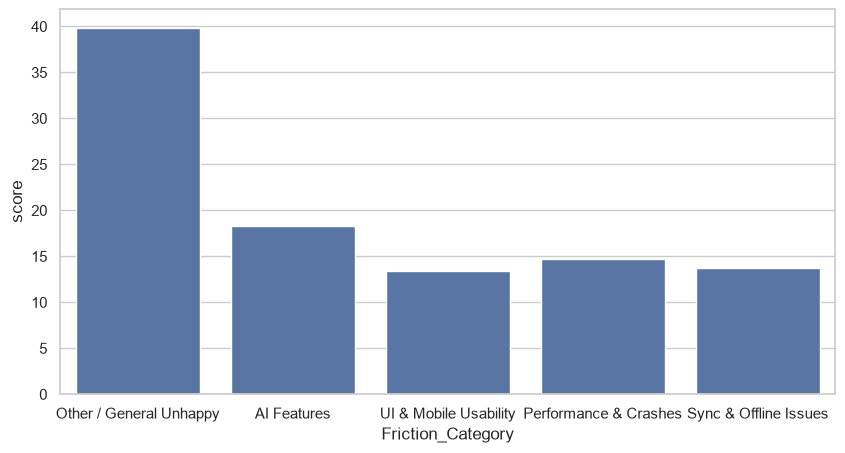

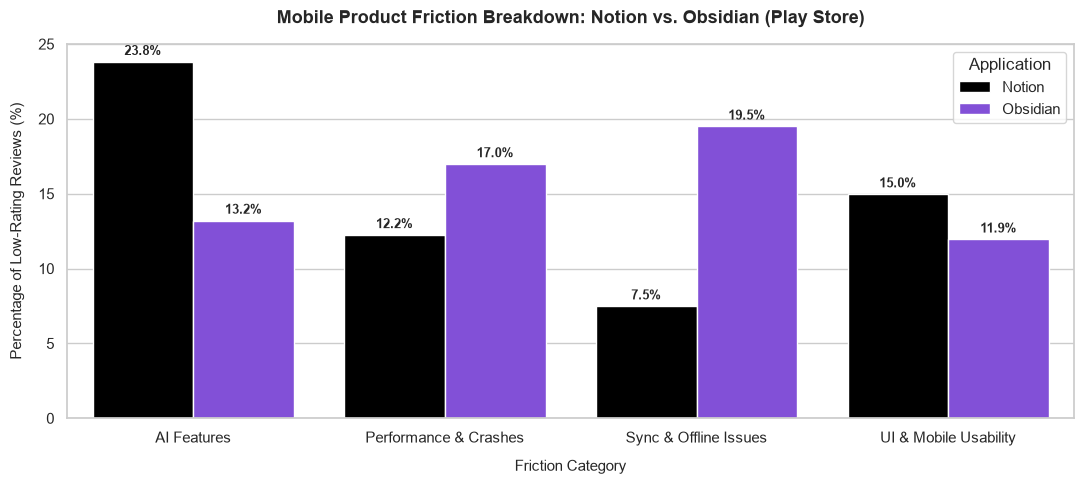

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Plot grouped bar chart
ax = sns.barplot(
    data=df_friction,
    x='Friction_Category',
    y='score', # temporary placeholder, we'll plot percentages from theme_comparison
    estimator=lambda x: len(x) / len(df_friction) * 100, # or plot theme_comparison directly
    ci=None
)

# Better approach: Melt or plot theme_comparison directly
theme_comparison_df = theme_comparison.reset_index().melt(
    id_vars='App',
    var_name='Friction_Category',
    value_name='Percentage'
)

# Filter out "Other / General Unhappy" to focus on actionable product feedback
theme_comparison_filtered = theme_comparison_df[theme_comparison_df['Friction_Category'] != 'Other / General Unhappy']

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=theme_comparison_filtered,
    x='Friction_Category',
    y='Percentage',
    hue='App',
    palette=['#000000', '#7C3AED'] # Notion (Black), Obsidian (Purple)
)

plt.title('Mobile Product Friction Breakdown: Notion vs. Obsidian (Play Store)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Friction Category', fontsize=11, labelpad=10)
plt.ylabel('Percentage of Low-Rating Reviews (%)', fontsize=11, labelpad=10)
plt.legend(title='Application')

# Add values above bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()

In [19]:
import pandas as pd
import urllib.request
import xml.etree.ElementTree as ET

def fetch_reddit_rss(subreddit, app_name):
    # RSS feeds use Atom XML and bypass JSON rate limits
    url = f"https://www.reddit.com/r/{subreddit}/new.rss"

    # Request header mimicking an RSS Reader
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; FeedReader/1.0)'}
    )

    try:
        with urllib.request.urlopen(req) as response:
            xml_data = response.read()

        root = ET.fromstring(xml_data)
        ns = {'atom': 'http://www.w3.org/2005/Atom'}

        posts = []
        for entry in root.findall('atom:entry', ns):
            title_node = entry.find('atom:title', ns)
            content_node = entry.find('atom:content', ns)
            updated_node = entry.find('atom:updated', ns)

            title = title_node.text if title_node is not None else ''
            # Strip out basic HTML tags from RSS content
            raw_content = content_node.text if content_node is not None else ''
            clean_content = f"{title} - {raw_content}"

            posts.append({
                'App': app_name,
                'Source': f'r/{subreddit}',
                'title': title,
                'content': clean_content,
                'created_at': updated_node.text if updated_node is not None else ''
            })

        print(f"Successfully fetched {len(posts)} posts from r/{subreddit} via RSS")
        return pd.DataFrame(posts)

    except Exception as e:
        print(f"Error fetching r/{subreddit} RSS: {e}")
        return pd.DataFrame()

# Fetch recent posts from both subreddits
df_reddit_notion = fetch_reddit_rss('Notion', 'Notion')
df_reddit_obsidian = fetch_reddit_rss('ObsidianMD', 'Obsidian')

# Combine datasets
df_reddit = pd.concat([df_reddit_notion, df_reddit_obsidian], ignore_index=True)

# Inspect the fetched RSS entries
if not df_reddit.empty:
    display(df_reddit[['App', 'Source', 'title', 'created_at']].head(10))

Successfully fetched 25 posts from r/Notion via RSS
Error fetching r/ObsidianMD RSS: HTTP Error 429: Too Many Requests


,App,Source,title,created_at
0,Notion,r/Notion,Making My Notion Cute/Aesthetic!,2026-09-27T18:34:09+00:00
1,Notion,r/Notion,Why Does Notion Think Browser Access is Disabled?,2026-09-27T17:55:52+00:00
2,Notion,r/Notion,"Customise Layout ""Views"" property block",2026-09-27T16:25:21+00:00
3,Notion,r/Notion,Is it possible to move your Notion calendar in...,2026-09-27T15:16:30+00:00
4,Notion,r/Notion,How to paste context into notion's table with ...,2026-09-27T15:01:36+00:00
5,Notion,r/Notion,Does anyone else have a graveyard of Notion Ch...,2026-09-27T13:34:25+00:00
6,Notion,r/Notion,Built an automated Cash Flow & CFO OS in Notio...,2026-09-27T10:09:16+00:00
7,Notion,r/Notion,"Canvas, please!",2026-09-27T09:25:40+00:00
8,Notion,r/Notion,I created a property that tracks the time I'm ...,2026-09-27T08:58:22+00:00
9,Notion,r/Notion,How can I stop Notion from double spacing?,2026-09-27T05:48:51+00:00


In [22]:
# Friction keywords common on Reddit product forums
friction_keywords = ['issue', 'bug', 'slow', 'sync', 'lag', 'switch', 'graveyard', 'frustrated', 'alternative', 'problem', 'help', 'why']

# Filter Reddit posts containing friction signals
df_reddit['is_friction'] = df_reddit['content'].str.lower().apply(
    lambda x: any(kw in str(x) for kw in friction_keywords)
)

df_reddit_friction = df_reddit[df_reddit['is_friction']].copy()

print(f"Total Reddit friction posts identified: {len(df_reddit_friction)}")
print("\n--- NOTION REDDIT FRICTION SAMPLE ---")
for title in df_reddit_friction[df_reddit_friction['App'] == 'Notion']['title'].head(4):
    print(f"• {title}")

print("\n--- OBSIDIAN REDDIT FRICTION SAMPLE ---")
for title in df_reddit_friction[df_reddit_friction['App'] == 'Obsidian']['title'].head(11):
    print(f"• {title}")

Total Reddit friction posts identified: 11

--- NOTION REDDIT FRICTION SAMPLE ---
• Making My Notion Cute/Aesthetic!
• Why Does Notion Think Browser Access is Disabled?
• Is it possible to move your Notion calendar into the notion database?
• Does anyone else have a graveyard of Notion Chats? ☠

--- OBSIDIAN REDDIT FRICTION SAMPLE ---
